In [101]:
import matplotlib.pyplot as plt
import torch
from cryosim.pdb2mrc import PDB2MRC
from cryosim.plotting_tools import *
from cryosim.crowding import poisson_disk_neighbors, insert_particles_into_micrograph, poisson_disk_neighbors_3d_fast
from cryosim.icemaker import Icemaker
from matplotlib.collections import PatchCollection
from cryosim.rotations import random_quaternion, quaternion_to_rotation_matrix, rotate_volume, build_affine_matrix
import numpy as np
from cryosim.fft_tools import fftn
import time
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# fetch pdb file
# note: warnings are from biopython, can be ignored.
pdb_code = "6bdf"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/", assembly=1)

Assemblies available: 1
6bdf: Fetching Biological Assembly 1
File already exists: ../pdb-data/6bdf-assembly1.cif, skip fetching.
Parsing ../pdb-data/6bdf-assembly1.cif.


Extracting atom coordinates and element: 46382it [00:00, 175935.55it/s]


In [3]:
# Samples 3D scattering potential onto specified grid
n = 256  # number of pixels per axis
dx = 1  # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

Building element S: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  3.56it/s]


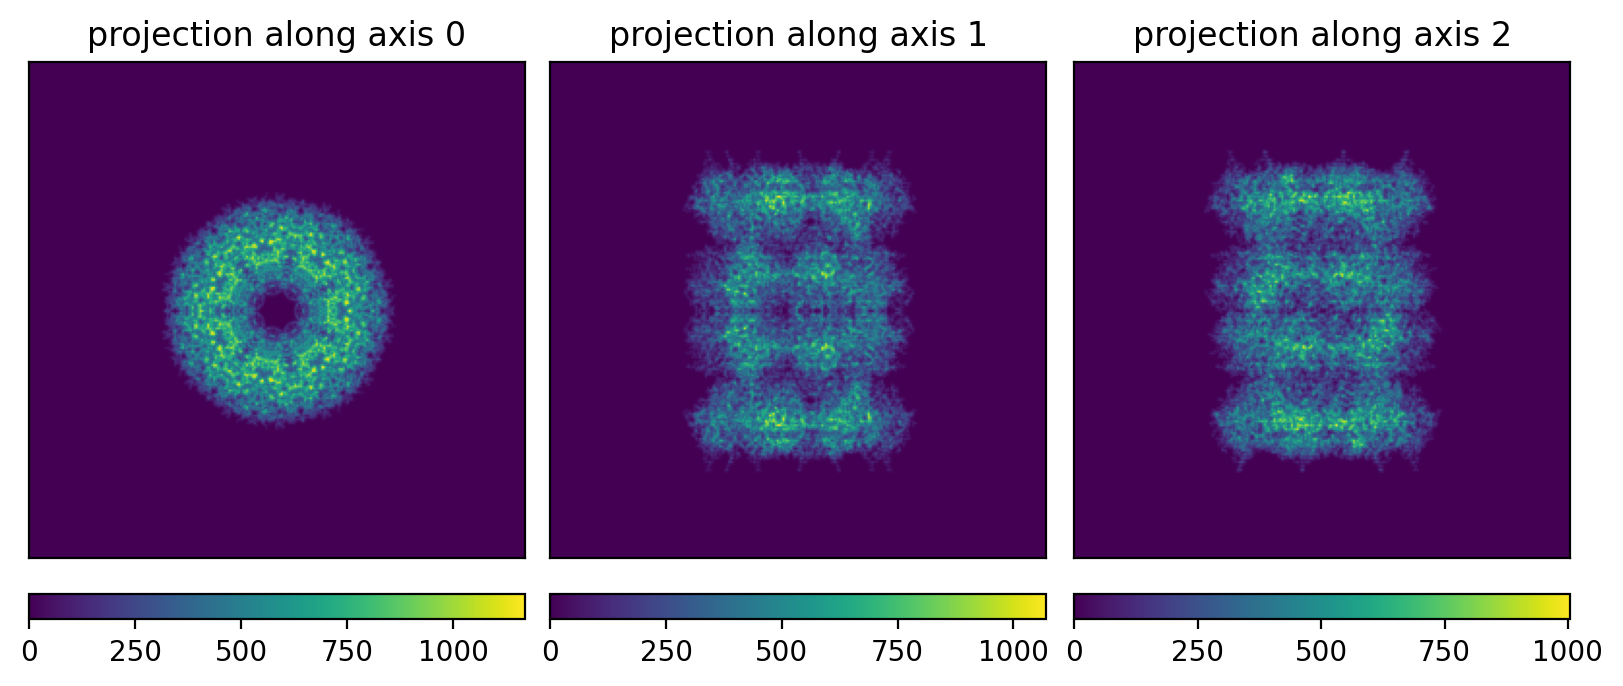

In [4]:
plot3d(V)

## Create micrograph

In [40]:
V.shape[1:]

torch.Size([256, 256])

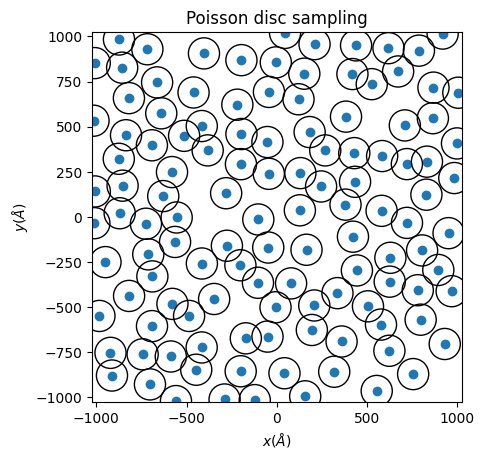

In [110]:
nxy = 2048
nz = 256
coords = poisson_disk_neighbors_3d_fast(pm.max_diameter * 0.9, 
                                        box=(nz*dx - pm.max_diameter/2, nxy*dx, nxy*dx), 
                                        seed='random')

x = coords[:,0]
y = coords[:,1]
z = coords[:,2]

fig = plt.figure()
# ax = fig.add_subplot(projection='3d')
# _ = ax.scatter(-x, y, z)
ax = fig.add_subplot()
_ = ax.scatter(-x, y)
circles = [plt.Circle((-xi, yi), radius=pm.max_diameter*0.9 / 2, fill=False) for xi, yi in zip(x,y)]
collection = PatchCollection(circles, match_original=True)
ax.add_collection(collection)
_ = ax.set(
    aspect="equal", xlabel=r"$x (\AA)$", ylabel=r"$y (\AA)$", xlim=[-dx*nxy/2, dx*nxy/2], ylim=[-dx*nxy/2, dx*nxy/2]
)
ax.set_title('Poisson disc sampling')

plt.show()

In [111]:
N = len(coords)
quaternions = random_quaternion(N)
rm = quaternion_to_rotation_matrix(quaternions)
am = build_affine_matrix(rm)
vols = rotate_volume(V, am)

In [112]:
vols.shape

torch.Size([120, 256, 256, 256])

In [113]:
nz = 256
micro = insert_particles_into_micrograph((nz, nxy, nxy), vols, coords, pixel_size=dx)

In [114]:
micro.shape

torch.Size([256, 2048, 2048])

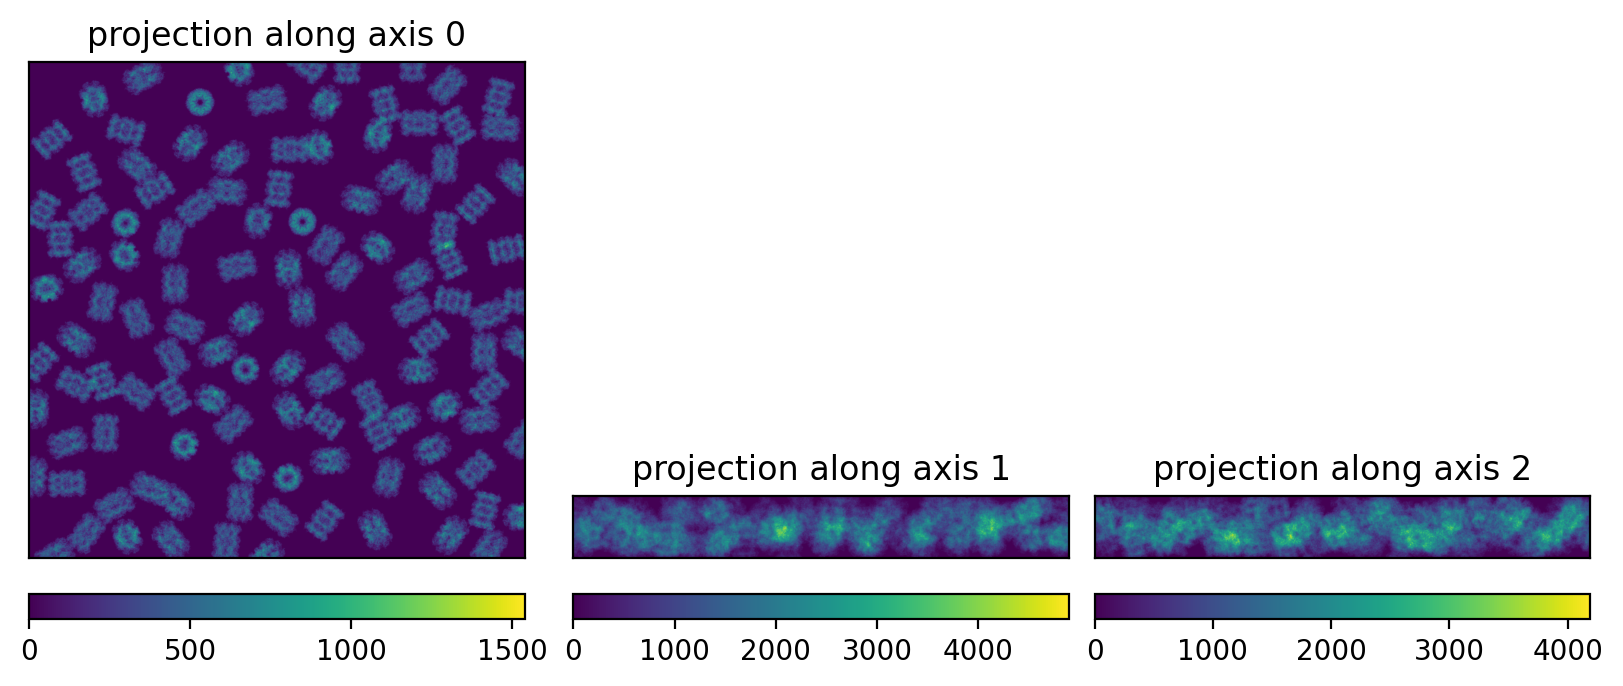

In [115]:
plot3d(micro)

In [96]:
im = Icemaker(n=256, dx=dx, nz=256, verbose=False)

In [108]:
t0 = time.perf_counter()
ice = im.generate_ice(batchsize=4)
t1 = time.perf_counter()
print(t1-t0)

9.753450838848948


In [105]:
im128 = Icemaker(n=128, dx=dx, nz=128, verbose=False)

In [109]:
t0 = time.perf_counter()
ice128 = im128.generate_ice(batchsize=4*8)
t1 = time.perf_counter()
print(t1-t0)

9.31198815535754


In [104]:
ice128.shape

torch.Size([4, 256, 256, 256])

In [145]:
icemask = torch.ones_like(micro)
icemask[micro>10] = 0

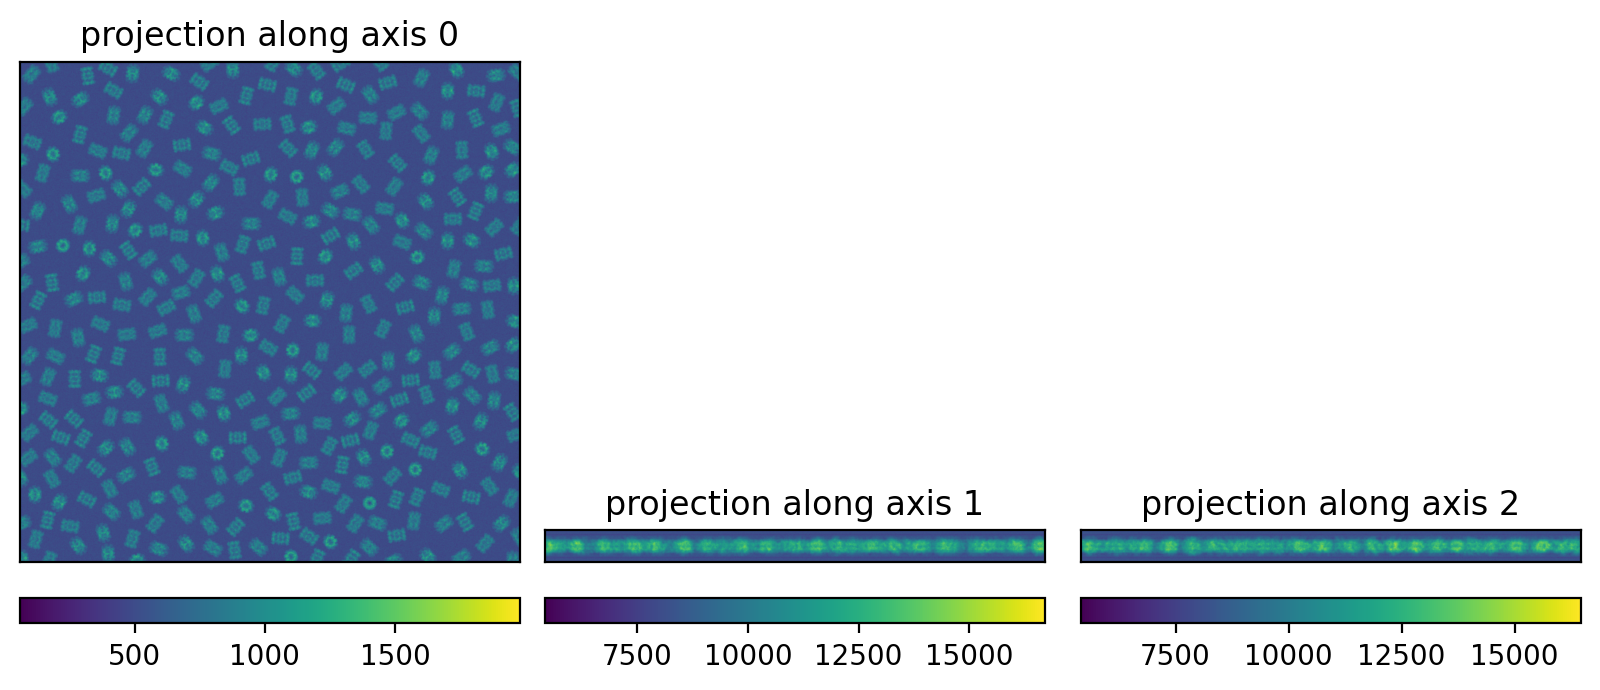

In [146]:
plot3d(ice[0] * icemask + micro)

In [43]:
im = Icemaker(n=256, dx=0.25, nz=256, verbose=False)

In [44]:
ice = im.generate_ice(batchsize=4)

In [45]:
ice.shape

torch.Size([4, 256, 256, 256])

In [46]:
import torch
import torch.nn.functional as F

def tile4_and_prune_sparse(volumes, min_distance=1):
    """
    Tile 4 volumes (4,Z,Y,X) into a 2x2 grid with shape (Z,2*Y,2*X)
    and prune only adjacent voxels at internal seams using min_distance.
    """
    if volumes.shape[0] != 4:
        raise ValueError("Input must have 4 volumes along dim 0")

    _, Z, Y, X = volumes.shape

    # Tile 2x2
    top = torch.cat([volumes[0], volumes[1]], dim=2)
    bottom = torch.cat([volumes[2], volumes[3]], dim=2)
    large_vol = torch.cat([top, bottom], dim=1)  # shape: (Z,2*Y,2*X)

    # ---- Prune internal X seam ----
    x_seam = X
    slab = large_vol[:, :, x_seam-min_distance:x_seam+min_distance].float().unsqueeze(0).unsqueeze(0)
    # Max-pool along X with stride = min_distance
    pooled = F.max_pool3d(slab, kernel_size=(1,1,2*min_distance+1), stride=(1,1,min_distance), padding=(0,0,0))
    # Expand pooled back to original slab width
    pooled_expanded = pooled.repeat(1,1,1,1,(2*min_distance+1))
    pooled_expanded = pooled_expanded[:, :, :, :, :slab.shape[-1]]
    # Keep only max voxel in each window
    mask = (slab == pooled_expanded)
    large_vol[:, :, x_seam-min_distance:x_seam+min_distance] = large_vol[:, :, x_seam-min_distance:x_seam+min_distance] * mask[0,0]

    # ---- Prune internal Y seam ----
    y_seam = Y
    slab = large_vol[:, y_seam-min_distance:y_seam+min_distance, :].float().unsqueeze(0).unsqueeze(0)
    pooled = F.max_pool3d(slab, kernel_size=(1,2*min_distance+1,1), stride=(1,min_distance,1), padding=(0,0,0))
    pooled_expanded = pooled.repeat(1,1,1,(2*min_distance+1),1)
    pooled_expanded = pooled_expanded[:, :, :, :slab.shape[1], :]
    mask = (slab == pooled_expanded)
    large_vol[:, y_seam-min_distance:y_seam+min_distance, :] = large_vol[:, y_seam-min_distance:y_seam+min_distance, :] * mask[0,0]

    return la

def tile4_volumes(volumes):
    """
    Tile 4 volumes (4, Z, Y, X) into a 2x2 grid -> (Z, 2*Y, 2*X)

    Args:
        volumes: torch tensor of shape (4, Z, Y, X)

    Returns:
        large_vol: torch tensor of shape (Z, 2*Y, 2*X)
    """
    if volumes.shape[0] != 4:
        raise ValueError("Input must have 4 volumes along dim 0")

    _, Z, Y, X = volumes.shape

    # Tile top row (vol0 | vol1) along X
    top = torch.cat([volumes[0], volumes[1]], dim=2)  # shape: (Z, Y, 2*X)
    # Tile bottom row (vol2 | vol3) along X
    bottom = torch.cat([volumes[2], volumes[3]], dim=2)  # shape: (Z, Y, 2*X)
    # Stack top and bottom rows along Y
    large_vol = torch.cat([top, bottom], dim=1)  # shape: (Z, 2*Y, 2*X)

    return large_vol


In [47]:
ice.shape

torch.Size([4, 256, 256, 256])

In [48]:
test = tile4_volumes(ice)

In [49]:
pooled = F.max_pool3d(test[None, None, ...], kernel_size=2, stride=1)

In [50]:
pooled.shape

torch.Size([1, 1, 255, 511, 511])

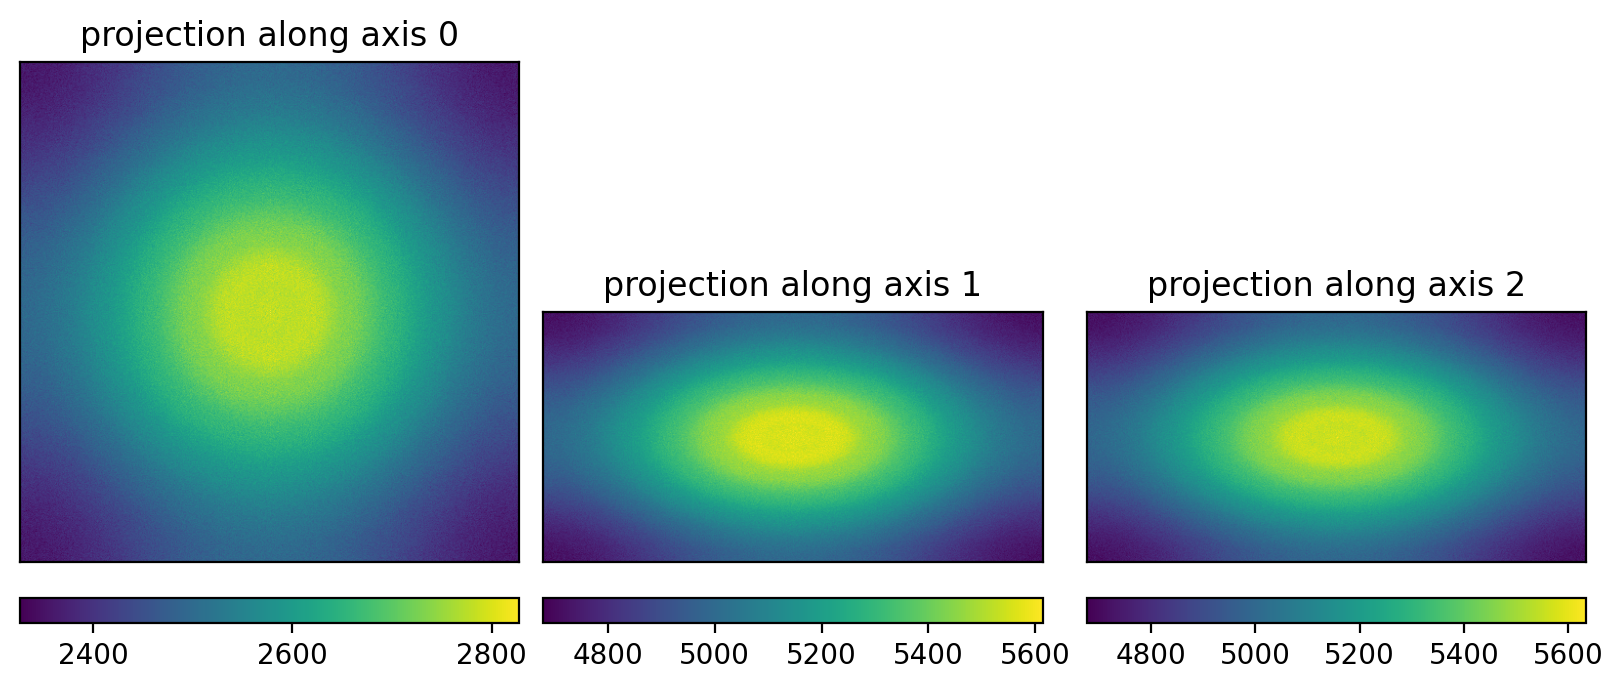

In [51]:
plot3d(torch.log(torch.abs(fftn(test.squeeze()))))

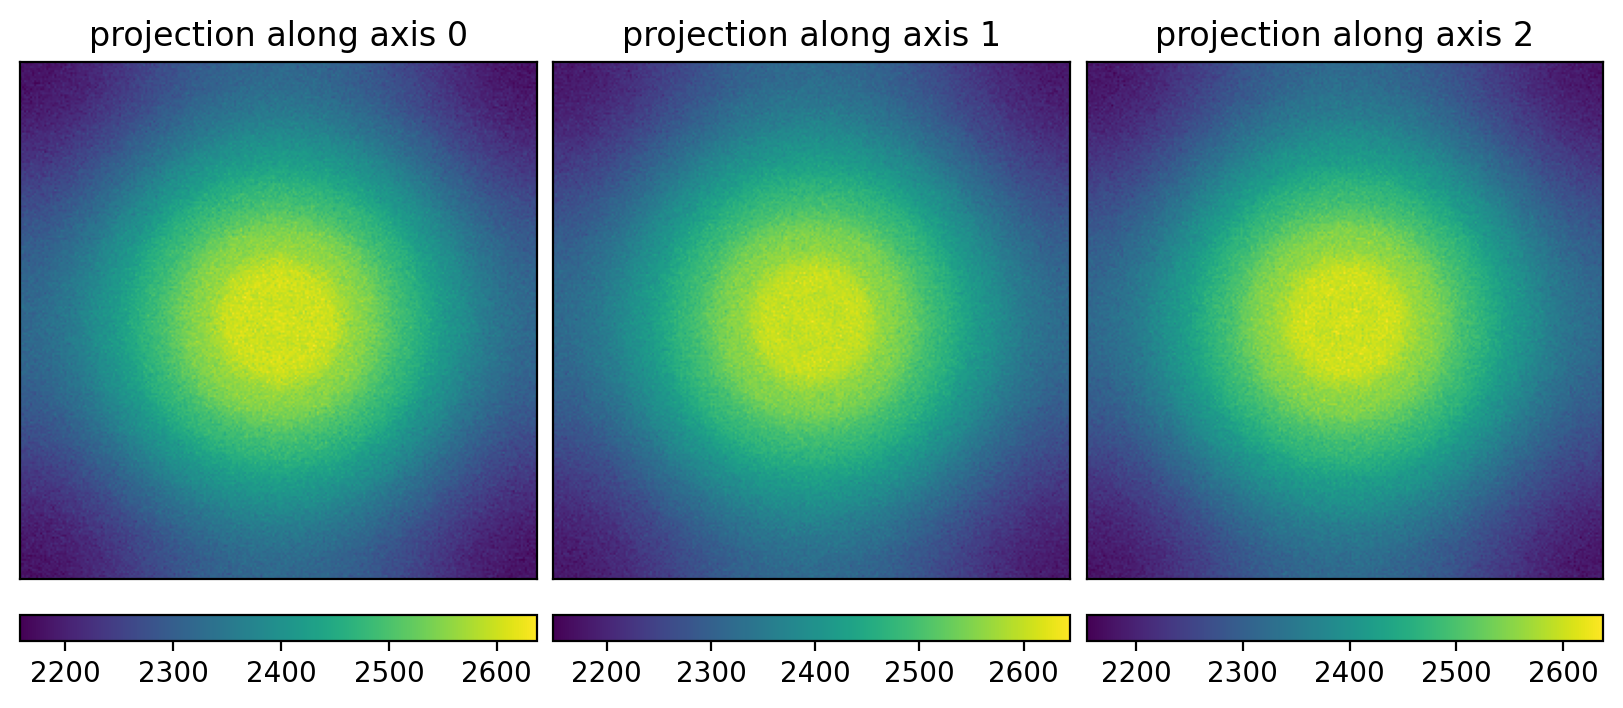

In [52]:
plot3d(torch.log(torch.abs(fftn(ice[0]))))

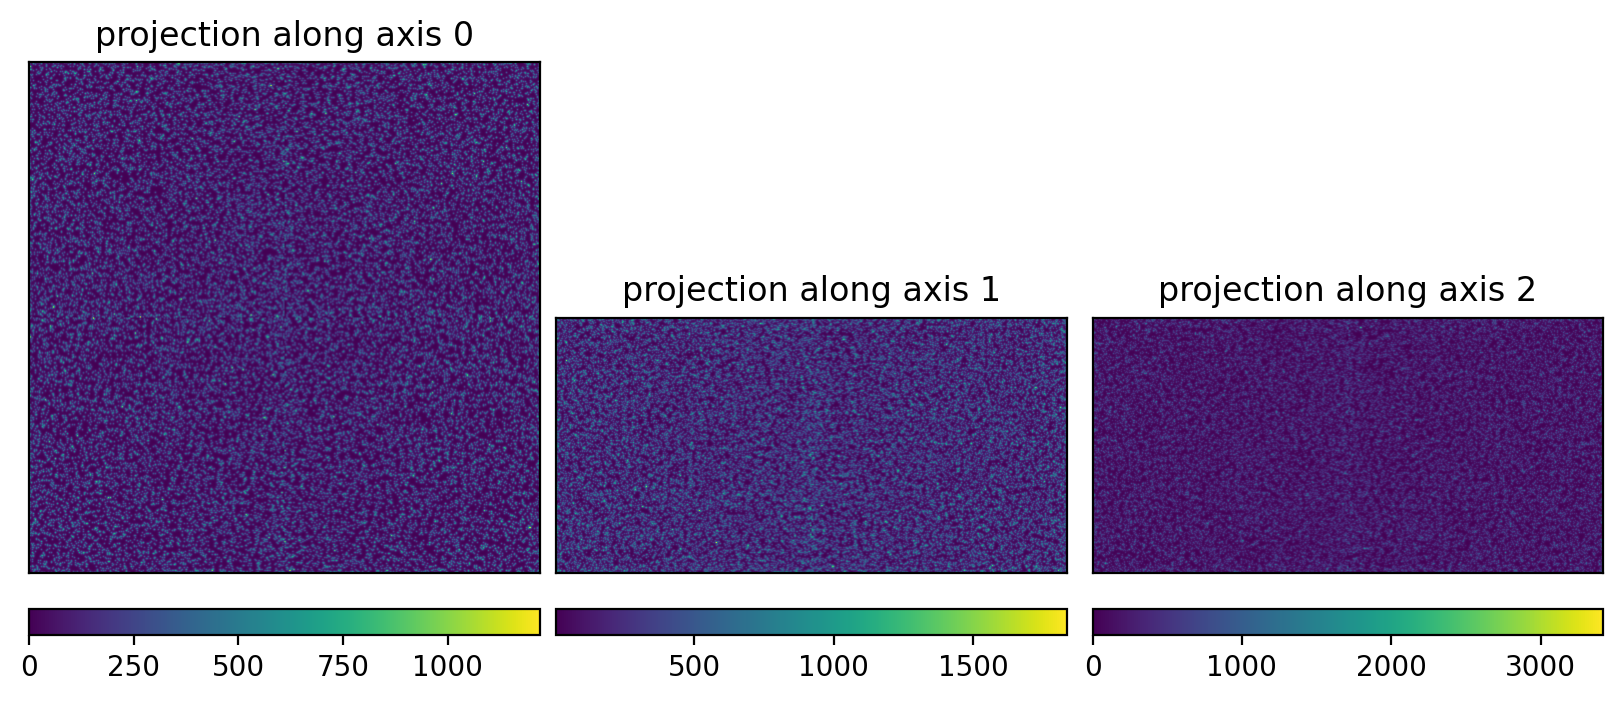

In [53]:
plot3d(test)